# Benchmark Data Analysis

This notebook analyzes the verification benchmark data from `data.json` and calculates median values for:
- `duration_ms`: Total verification duration in milliseconds
- `user_time_secs`: User CPU time in seconds
- `system_time_secs`: System CPU time in seconds

## 1. Load and Parse JSON Data

In [1]:
import json
import os
from pathlib import Path
import numpy as np

def first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return paths[0]

# Resolve baseline benchmark data files from common locations
benchmark_files = {
    "TPCC": first_existing([
        "./data_out/tpcc_out/61920/data.json",
        "./data_out/tpcc_out/data.json",
        "./tpcc_out/data.json",
    ]),
    "Social": first_existing([
        "./data_out/social_out/data.json",
        "./social_out/data.json",
    ]),
    "RUBiS": first_existing([
        "./data_out/rubis_out/data.json",
        "./rubis_out/data.json",
    ]),
}

# Automatically include benchbase-transact outputs
benchbase_root = Path("./data_out/benchbase_transact_out")
if benchbase_root.exists():
    for p in sorted(benchbase_root.glob("*/data.json")):
        benchmark_files[f"benchbase:{p.parent.name}"] = str(p)

# Load JSON data
topdatasets = {}
required = {"TPCC", "Social", "RUBiS"}
missing_optional = []
for name, path in benchmark_files.items():
    if not os.path.exists(path):
        if name in required:
            raise FileNotFoundError(f"Missing required benchmark data file for {name}: {path}")
        missing_optional.append((name, path))
        continue
    with open(path, "r") as f:
        topdatasets[name] = json.load(f)

print("Loaded files:")
for name in sorted(topdatasets.keys()):
    print(f"  {name}: {benchmark_files[name]}")

if missing_optional:
    print("\nOptional datasets missing data.json (skipped):")
    for name, path in missing_optional:
        print(f"  {name}: {path}")

# Also report benchbase runs that completed but had 0 verifications (no data.json emitted)
run_results_path = benchbase_root / "run_results.tsv"
if run_results_path.exists():
    no_data_benchmarks = []
    with open(run_results_path, "r") as f:
        lines = [line.strip().split("\t") for line in f if line.strip()]
    for row in lines[1:]:
        if len(row) >= 6 and row[5].strip() == "no":
            no_data_benchmarks.append(row[0].strip())
    if no_data_benchmarks:
        print("\nBenchbase benchmarks with 0 C-edge verifications (no data.json by design):")
        print("  " + ", ".join(sorted(no_data_benchmarks)))

print("\nHigh-level verification stats:")
for name, data in topdatasets.items():
    total_verifications = len(data["c_edge_verifications"])
    passed_verifications = sum(1 for v in data["c_edge_verifications"] if v["result"] == "Pass")
    failed_verifications = sum(1 for v in data["c_edge_verifications"] if v["result"] == "Error")
    timeout_verifications = sum(1 for v in data["c_edge_verifications"] if v["result"] == "Timeout")
    print(f"{name}: total={total_verifications}, pass={passed_verifications}, error={failed_verifications}, timeout={timeout_verifications}")

# Build per-edge feature records for later analysis (Section 5)
feature_records = []
for benchmark_name, data in topdatasets.items():
    for v in data["c_edge_verifications"]:
        record = {
            "benchmark": benchmark_name,
            "duration_ms": float(v["duration_ms"]),
            "duration_secs": float(v["duration_ms"]) / 1000.0,
            "boogie_file_len": float(v.get("boogie_file_len", 0)),
            "real_procedure_len": float(v.get("real_procedure_len", 0)),
            "branch_count": float(v.get("branch_count", 0)),
            "has_loop": 1.0 if v.get("has_loop", False) else 0.0,
            "db_read_count": float(v.get("db_read_count", 0)),
            "db_write_count": float(v.get("db_write_count", 0)),
            "db_total_access": float(v.get("db_read_count", 0) + v.get("db_write_count", 0)),
            "result": v.get("result", "Unknown"),
        }
        feature_records.append(record)

print(f"\nTotal feature records: {len(feature_records)}")

# Keep these variables for existing histogram sections (Sections 2-4)
tpcc_data = topdatasets["TPCC"]
social_data = topdatasets["Social"]
rubis_data = topdatasets["RUBiS"]

Loaded files:
  RUBiS: ./rubis_out/data.json
  Social: ./social_out/data.json
  TPCC: ./tpcc_out/data.json
  benchbase:auctionmark: data_out/benchbase_transact_out/auctionmark/data.json
  benchbase:epinions: data_out/benchbase_transact_out/epinions/data.json
  benchbase:resourcestresser: data_out/benchbase_transact_out/resourcestresser/data.json
  benchbase:sibench: data_out/benchbase_transact_out/sibench/data.json
  benchbase:smallbank: data_out/benchbase_transact_out/smallbank/data.json
  benchbase:tatp: data_out/benchbase_transact_out/tatp/data.json
  benchbase:twitter: data_out/benchbase_transact_out/twitter/data.json
  benchbase:voter: data_out/benchbase_transact_out/voter/data.json
  benchbase:wikipedia: data_out/benchbase_transact_out/wikipedia/data.json
  benchbase:ycsb: data_out/benchbase_transact_out/ycsb/data.json
  benchbase:ycsb_null: data_out/benchbase_transact_out/ycsb_null/data.json

Benchbase benchmarks with 0 C-edge verifications (no data.json by design):
  tpcds, tpc

## 2. Extract Duration

In [2]:
# Extract metrics from all verifications
tpcc_duration_ms_values = []
social_duration_ms_values = []
rubis_duration_ms_values = []

def extract_metrics(data, duration_ms_values):
    for verification in data['c_edge_verifications']:
        # Extract duration_ms (always present)
        duration_ms_values.append(verification['duration_ms'])

extract_metrics(tpcc_data, tpcc_duration_ms_values)
extract_metrics(social_data, social_duration_ms_values)
extract_metrics(rubis_data, rubis_duration_ms_values)
# delete the greatest value in tpcc_duration_ms_values to avoid outlier
# tpcc_duration_ms_values.remove(max(tpcc_duration_ms_values))

# divide all duration values by 1000 to convert to seconds
tpcc_duration_ms_values = [x / 1000.0 for x in tpcc_duration_ms_values]
social_duration_ms_values = [x / 1000.0 for x in social_duration_ms_values]
rubis_duration_ms_values = [x / 1000.0 for x in rubis_duration_ms_values]


# Group datasets and their titles for easier processing
datasets = {
    "TPCC": tpcc_duration_ms_values,
    "Social": social_duration_ms_values,
    "RUBiS": rubis_duration_ms_values,
}

## 3. Visualize Distribution

/tmp/ipykernel_3767035/3406773805.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


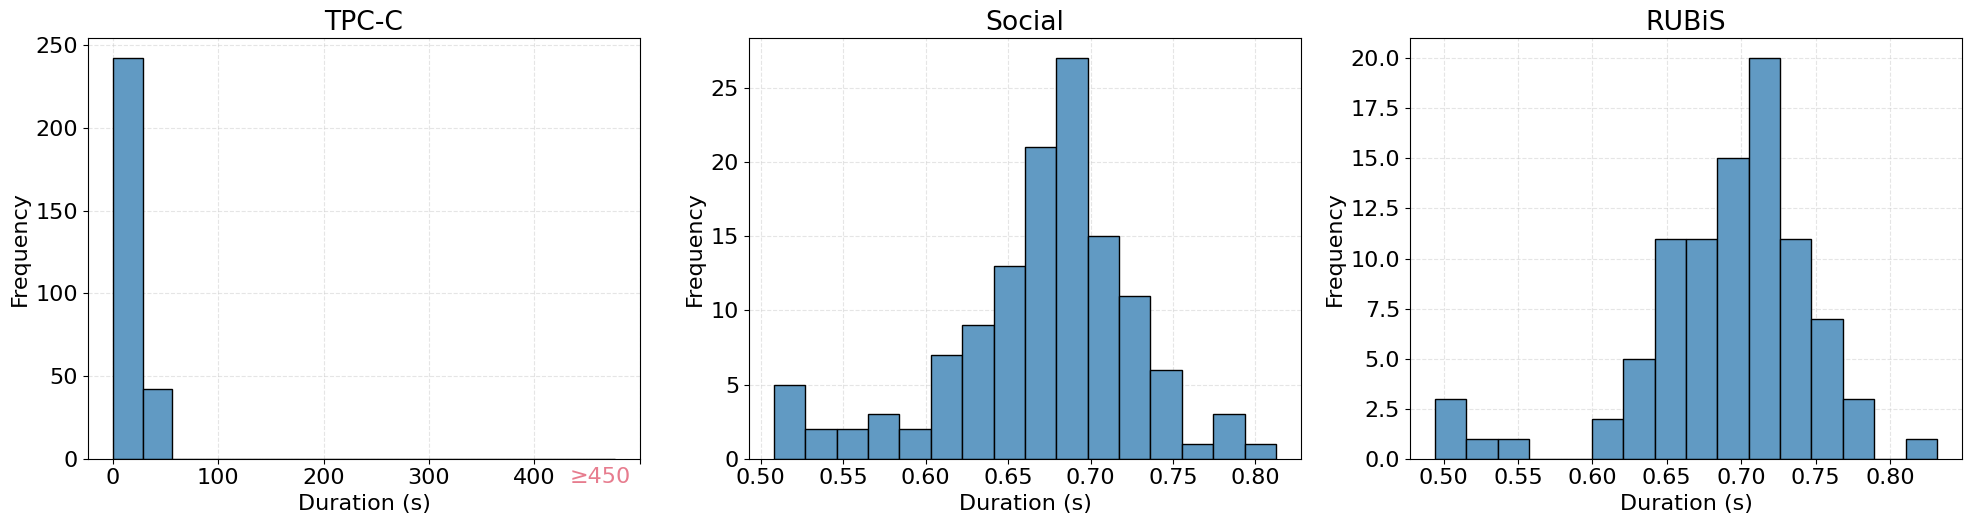

In [3]:
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np

# change to type1/truetype fonts: https://gecco-2025.sigevo.org/Paper-Submission-Instructions
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 16,
})

color_theme = {
    "myblue": (97/255, 154/255, 195/255),
    "myred": (231/255, 124/255, 142/255),
    "mygreen": (97/255, 172/255, 133/255),
    "myorange": (255/255, 153/255, 0/255),
    "edgecolor": "black",
    "gridcolor": "#cccccc",
    "linestyle": "--",
}

# --- Plotting Function ---
def create_histogram(ax, data, title, color_theme, use_log_scale=False, has_outlier=False, normal_range=None):
    """
    Creates a histogram, with an option to aggregate outliers into the last bin,
    which is colored differently and specially labeled.
    """
    # --- 1. Initial Setup and Validation ---
    if data is None or len(data) == 0:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center')
        ax.set_title(title)
        return
    if title is not None:
        ax.set_title(title)
    
    # --- 2. Data and Bin Configuration ---
    data_to_plot = np.copy(data)
    num_bins = 16 # Set the desired number of bins
    bins = num_bins
    xlabel = 'Duration (s)'

    if has_outlier:
        if normal_range is None or len(normal_range) != 2:
            raise ValueError("`normal_range` must be a tuple of (min, max) when has_outlier is True.")
        
        cutoff = normal_range[1]
        plot_end = (normal_range[1] - normal_range[0]) / (num_bins + 1) + normal_range[1]
        # Ensure exactly `num_bins` are created for the range, making the last one the outlier bin.
        # `num_bins + 1` is used to define the correct number of bin edges.
        bins = np.linspace(normal_range[0], plot_end, num_bins + 2)
        data_to_plot[data_to_plot > cutoff] = cutoff

    elif use_log_scale:
        min_val = np.min(data)
        max_val = np.max(data)
        if min_val <= 0: min_val = 1
        bins = np.logspace(np.log10(min_val), np.log10(max_val), 50)
        ax.set_xscale('log')
        xlabel = 'Duration (s) [log scale]'

    # --- 3. Plotting ---
    _, _, patches = ax.hist(data_to_plot, bins=bins, color=color_theme["myblue"], edgecolor=color_theme["edgecolor"])
    ax.grid(True, which="both", ls=color_theme["linestyle"], color=color_theme["gridcolor"], alpha=0.5)
    ax.set_axisbelow(True)

    # --- 4. Final Labeling and Customization ---
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')

    if has_outlier:
        last_patch = patches[-1]

        outlier_face_color = color_theme["myred"]
        last_patch.set_facecolor(outlier_face_color)

        x_pos = last_patch.get_x() + last_patch.get_width() / 2
    
        ax.text(x_pos, -0.02, f'≥{int(cutoff)}', 
                transform=ax.get_xaxis_transform(),
                ha='center', va='top', color=outlier_face_color)

        ticks = ax.get_xticks()
        # print(ticks)
        labels = ax.get_xticklabels()
        for i, tick in enumerate(ticks):
            if tick >= cutoff:
                labels = labels[:i+1]
                ticks = ticks[:i+1]
                labels[i].set_visible(False)
                break
        # ax.set_xticks(ticks)
        ax.set_xticklabels(labels)

# --- Main Execution ---
# 1. Create the combined figure with three subplots in one row
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

create_histogram(axes[0], datasets["TPCC"], "TPC-C", color_theme, has_outlier=True, normal_range=(0, 450.0)) # use_log_scale=True) #has_outlier=True, normal_range=(0, 450.0))
create_histogram(axes[1], datasets["Social"], "Social", color_theme)
create_histogram(axes[2], datasets["RUBiS"], "RUBiS", color_theme)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4. Save figures without title

In [4]:
# Directory to save the figures
output_dir = "histogram_figures_out"
os.makedirs(output_dir, exist_ok=True) # Create the directory if it doesn't exist

print(f"Saving individual plots to '{output_dir}/' directory...")
for name, data in datasets.items():
    # Create a new, single figure for saving
    individual_fig, individual_ax = plt.subplots(figsize=(10, 6))
    if name == "TPCC":
        create_histogram(individual_ax, data, None, color_theme, has_outlier=True, normal_range=(0, 450.0)) # use_log_scale=True) #has_outlier=True, normal_range=(0, 450.0))
    else:
        create_histogram(individual_ax, data, None, color_theme, use_log_scale=False)
    
    # Define the output path and save the figure
    file_path = os.path.join(output_dir, f"{name.lower()}_histogram.pdf")
    individual_fig.savefig(file_path, bbox_inches='tight', format='pdf')
    
    # Close the figure to free up memory
    plt.close(individual_fig)


Saving individual plots to 'histogram_figures_out/' directory...


/tmp/ipykernel_3767035/3406773805.py:92: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


## 5. Feature Analysis for Verification Wall-Clock Time

Outlier summary by benchmark (duration_secs):
  TPCC: n=284, min=0.6411, median=0.9671, q99=31.1140, max=31.1599, n_above_q99=3
  Social: n=128, min=0.5081, median=0.6792, q99=0.7900, max=0.8124, n_above_q99=2
  RUBiS: n=91, min=0.4942, median=0.7012, q99=0.7871, max=0.8316, n_above_q99=1
  benchbase:auctionmark: n=220, min=0.5325, median=0.7367, q99=1.9859, max=2.0907, n_above_q99=3
  benchbase:epinions: n=40, min=0.4392, median=0.6104, q99=0.7066, max=0.7077, n_above_q99=1
  benchbase:resourcestresser: n=29, min=0.4450, median=0.5995, q99=0.7289, max=0.7296, n_above_q99=1
  benchbase:sibench: n=5, min=0.3977, median=0.4019, q99=0.4112, max=0.4114, n_above_q99=1
  benchbase:smallbank: n=99, min=0.4282, median=0.6397, q99=0.7355, max=0.7421, n_above_q99=1
  benchbase:tatp: n=40, min=0.4474, median=0.6598, q99=0.7469, max=0.7518, n_above_q99=1
  benchbase:twitter: n=1, min=0.3981, median=0.3981, q99=0.3981, max=0.3981, n_above_q99=0
  benchbase:voter: n=1, min=0.3915, median=0.3915, q99

/tmp/ipykernel_3767035/1172059629.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


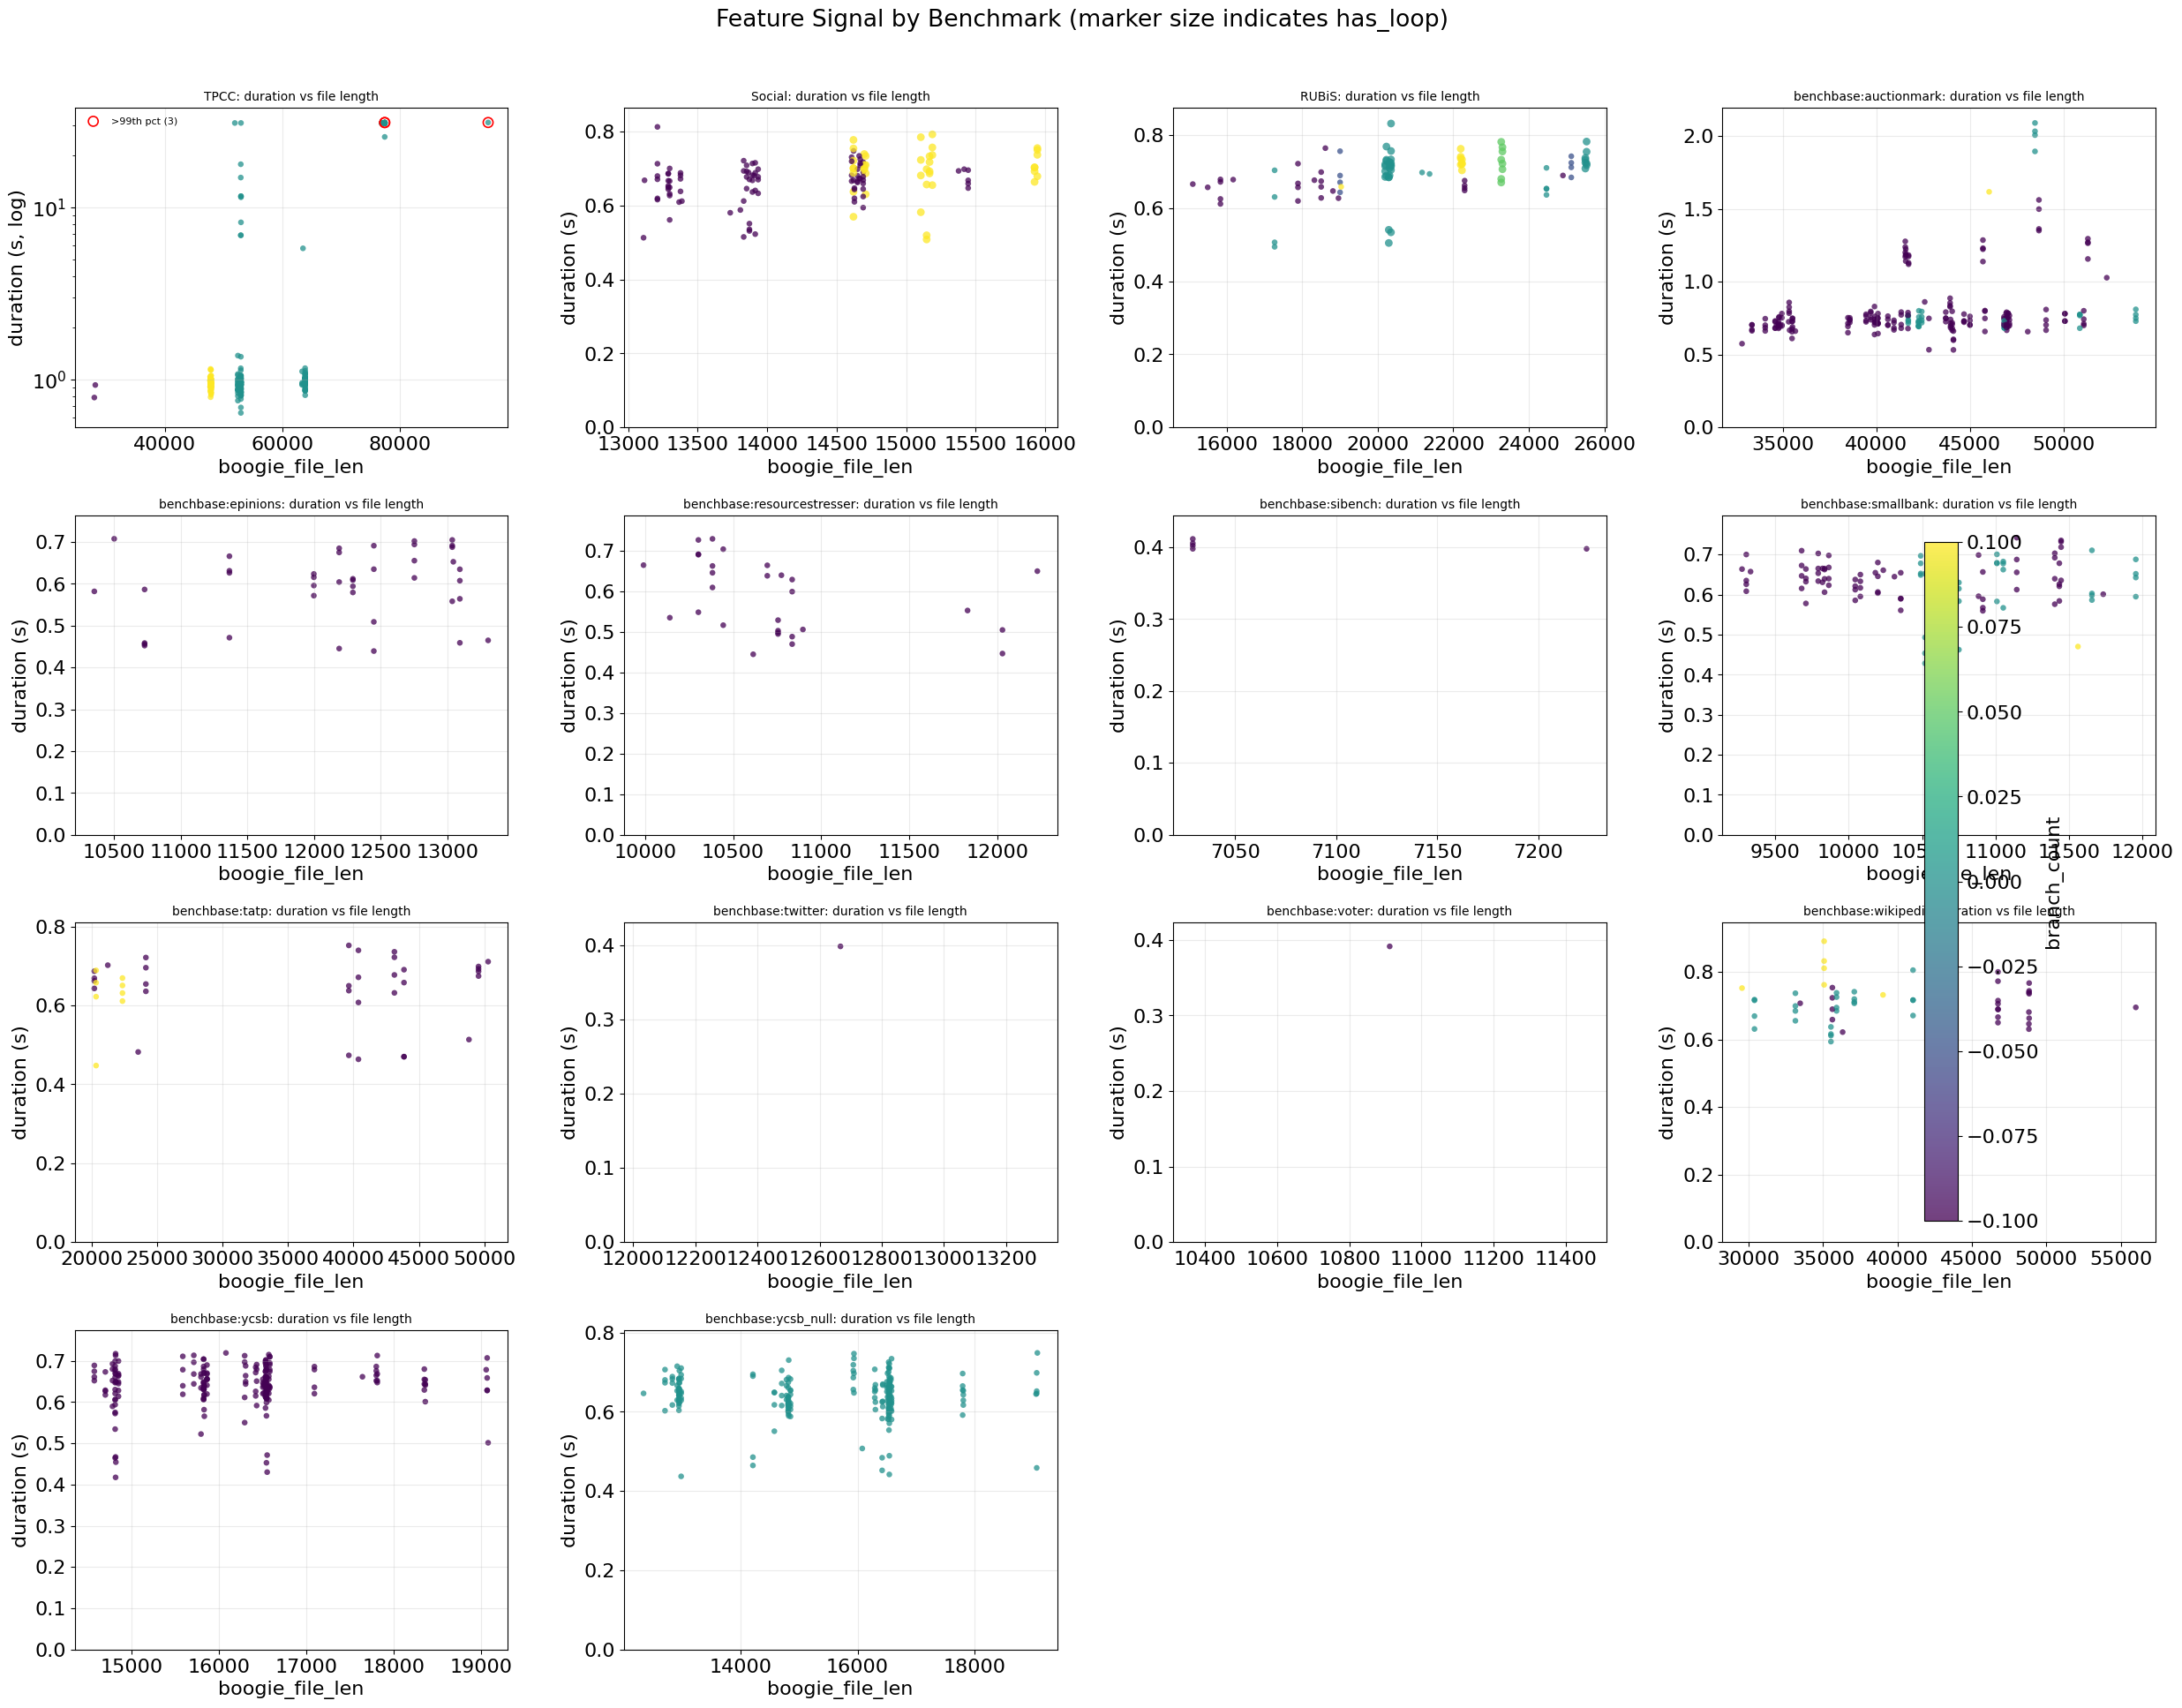

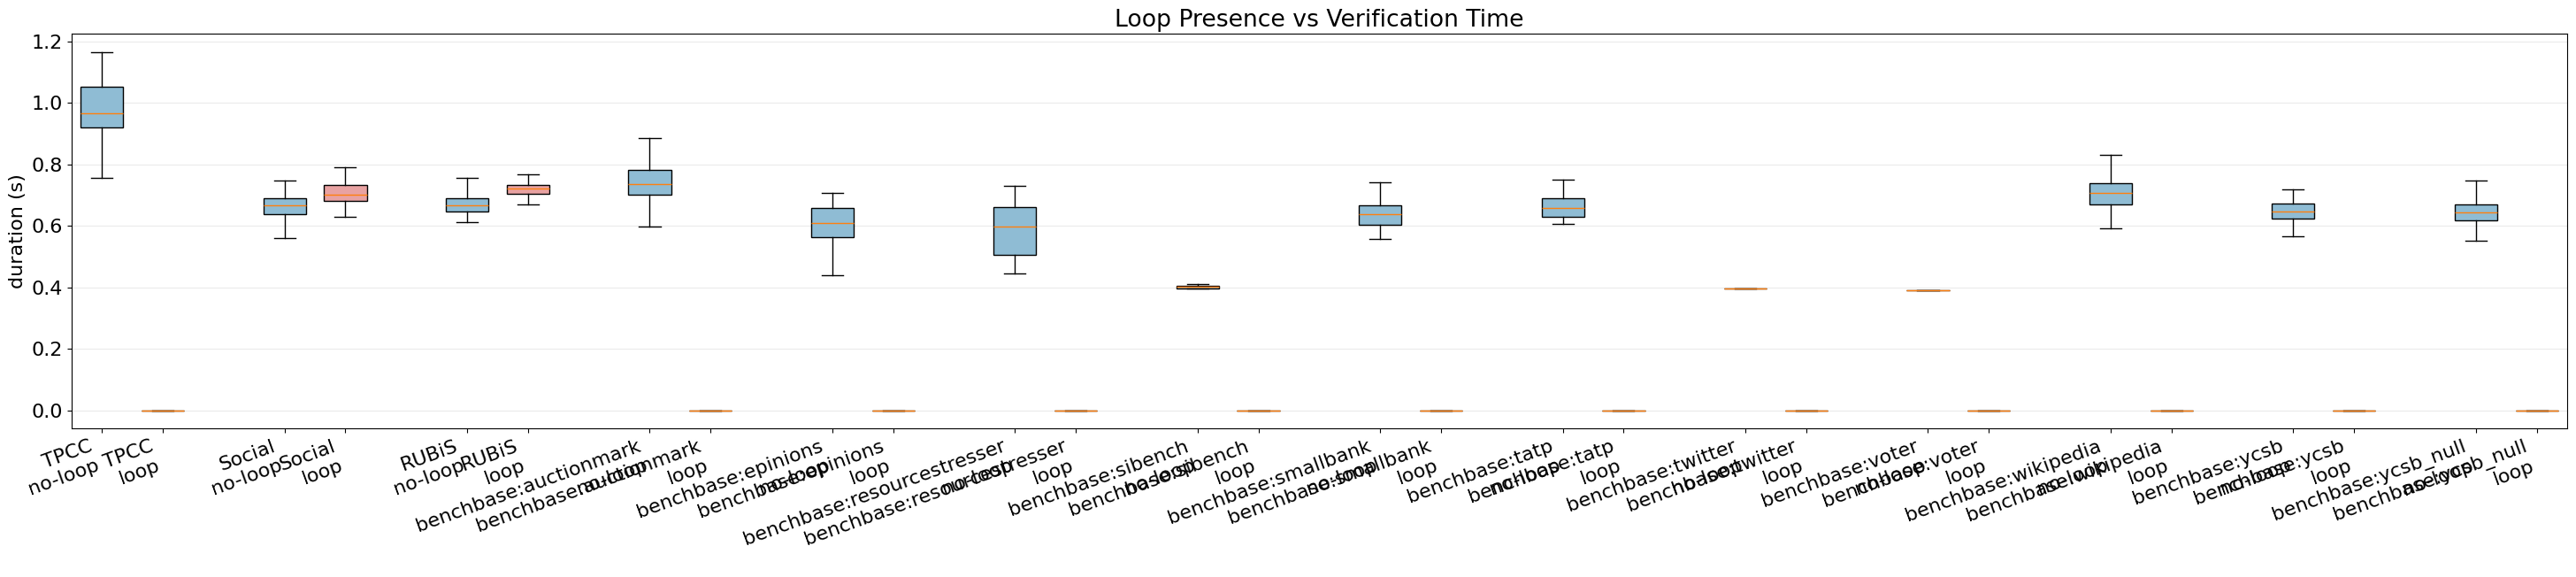

/tmp/ipykernel_3767035/1172059629.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


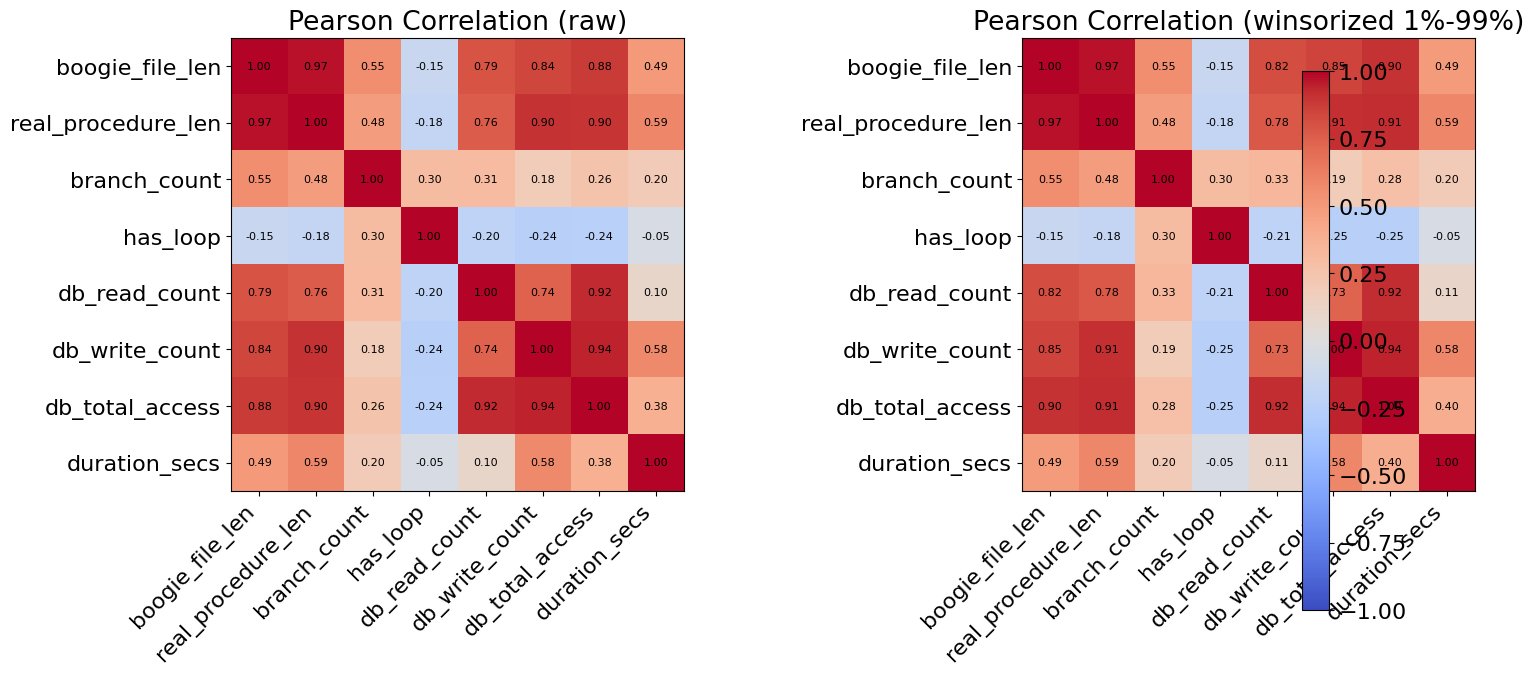

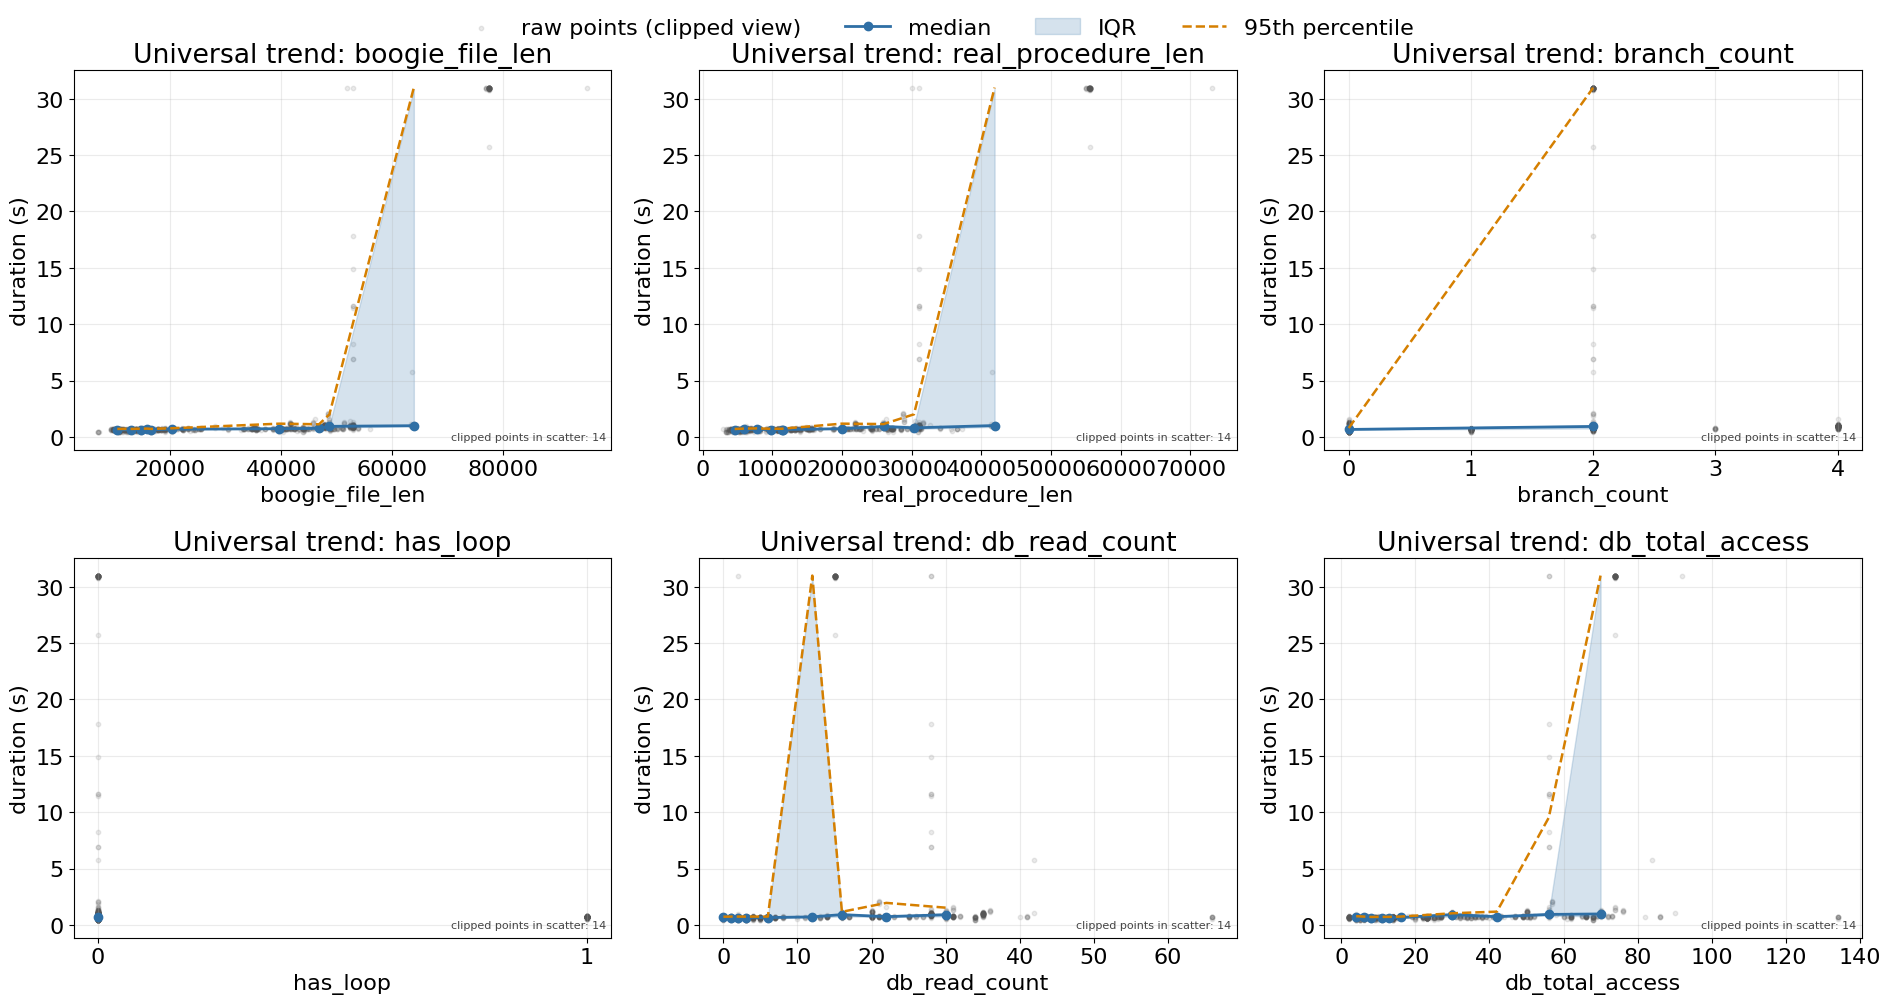

Feature analysis complete (TPCC log scale + outlier-aware universal views).


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Build benchmark order dynamically so newly added datasets are included automatically
default_order = ["TPCC", "Social", "RUBiS"]
present = sorted(set(r["benchmark"] for r in feature_records))
benchmarks = [b for b in default_order if b in present] + [b for b in present if b not in default_order]

records_by_benchmark = {
    name: [r for r in feature_records if r["benchmark"] == name]
    for name in benchmarks
}

def winsorize_columns(X, lower_q=0.01, upper_q=0.99):
    Xw = X.copy()
    for j in range(X.shape[1]):
        lo = np.quantile(X[:, j], lower_q)
        hi = np.quantile(X[:, j], upper_q)
        Xw[:, j] = np.clip(X[:, j], lo, hi)
    return Xw

print("Outlier summary by benchmark (duration_secs):")
for bench in benchmarks:
    y = np.array([r["duration_secs"] for r in records_by_benchmark[bench]], dtype=float)
    if len(y) == 0:
        print(f"  {bench}: no records")
        continue
    q99 = float(np.quantile(y, 0.99))
    print(
        f"  {bench}: n={len(y)}, min={y.min():.4f}, median={np.median(y):.4f}, "
        f"q99={q99:.4f}, max={y.max():.4f}, n_above_q99={(y > q99).sum()}"
    )

# ----------------------------
# Figure 5.1: Per-benchmark feature scatter (duration vs file length)
# TPCC uses log y-scale; other benchmarks use linear y-scale with independent ranges
# ----------------------------
n = len(benchmarks)
ncols = min(4, max(1, n))
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6.2 * ncols, 4.8 * nrows), sharey=False)
axes = np.array(axes).reshape(-1)

sc_for_colorbar = None
for i, bench in enumerate(benchmarks):
    ax = axes[i]
    recs = records_by_benchmark[bench]
    x = np.array([r["boogie_file_len"] for r in recs], dtype=float)
    y = np.array([r["duration_secs"] for r in recs], dtype=float)
    c = np.array([r["branch_count"] for r in recs], dtype=float)
    s = np.array([40 if r["has_loop"] > 0.5 else 22 for r in recs], dtype=float)

    if bench == "TPCC":
        y_plot = np.clip(y, 1e-3, None)
        sc = ax.scatter(x, y_plot, c=c, s=s, cmap="viridis", alpha=0.75, edgecolor="none")
        ax.set_yscale("log")
        ax.set_ylabel("duration (s, log)")

        tpcc_q99 = np.quantile(y, 0.99)
        is_outlier = y > tpcc_q99
        if np.any(is_outlier):
            ax.scatter(
                x[is_outlier],
                np.clip(y[is_outlier], 1e-3, None),
                s=64,
                facecolors="none",
                edgecolors="red",
                linewidths=1.2,
                label=f">99th pct ({is_outlier.sum()})",
            )
            ax.legend(loc="upper left", fontsize=8, frameon=False)
    else:
        sc = ax.scatter(x, y, c=c, s=s, cmap="viridis", alpha=0.75, edgecolor="none")
        ax.set_ylabel("duration (s)")
        y_cap = float(np.quantile(y, 0.995)) if len(y) > 1 else float(y.max())
        ax.set_ylim(0, max(y_cap * 1.08, 1e-6))

    ax.set_title(f"{bench}: duration vs file length", fontsize=10)
    ax.set_xlabel("boogie_file_len")
    ax.grid(alpha=0.25)
    sc_for_colorbar = sc

for j in range(n, len(axes)):
    axes[j].axis("off")

if sc_for_colorbar is not None:
    cbar = fig.colorbar(sc_for_colorbar, ax=axes.tolist(), shrink=0.78, fraction=0.02, pad=0.015)
    cbar.set_label("branch_count")

fig.suptitle("Feature Signal by Benchmark (marker size indicates has_loop)", y=1.01)
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 5.2: Loop vs non-loop wall-clock distribution by benchmark
# ----------------------------
fig, ax = plt.subplots(figsize=(max(14, 2.1 * len(benchmarks)), 6.8))

positions = []
box_data = []
labels = []
base = 1

for bench in benchmarks:
    recs = records_by_benchmark[bench]
    no_loop = [r["duration_secs"] for r in recs if r["has_loop"] < 0.5]
    has_loop = [r["duration_secs"] for r in recs if r["has_loop"] >= 0.5]

    box_data.extend([no_loop if no_loop else [0.0], has_loop if has_loop else [0.0]])
    positions.extend([base, base + 1])
    labels.extend([f"{bench}\nno-loop", f"{bench}\nloop"])
    base += 3

bp = ax.boxplot(box_data, positions=positions, widths=0.7, patch_artist=True, showfliers=False)
for j, patch in enumerate(bp["boxes"]):
    patch.set_facecolor("#8fbcd4" if j % 2 == 0 else "#e8a2a2")

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("duration (s)")
ax.set_title("Loop Presence vs Verification Time")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 5.3: Universal feature correlation heatmaps
# Left: raw Pearson, Right: winsorized Pearson (1%-99%)
# ----------------------------
feature_names = [
    "boogie_file_len",
    "real_procedure_len",
    "branch_count",
    "has_loop",
    "db_read_count",
    "db_write_count",
    "db_total_access",
    "duration_secs",
]

X = np.array([[r[f] for f in feature_names] for r in feature_records], dtype=float)
corr_raw = np.corrcoef(X, rowvar=False)
corr_winsor = np.corrcoef(winsorize_columns(X, 0.01, 0.99), rowvar=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, corr, title in [
    (axes[0], corr_raw, "Pearson Correlation (raw)"),
    (axes[1], corr_winsor, "Pearson Correlation (winsorized 1%-99%)"),
]:
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(np.arange(len(feature_names)))
    ax.set_xticklabels(feature_names, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(feature_names)))
    ax.set_yticklabels(feature_names)
    ax.set_title(title)
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.03, pad=0.02)
plt.tight_layout()
plt.show()

# ----------------------------
# Figure 5.4: Universal trend curves (median + IQR + p95), outlier-aware display
# Quantiles are computed on a clipped view so extreme points are visible but not dominant
# ----------------------------
def binned_trend(records, feature_key, bins=10, y_cap=None):
    x = np.array([r[feature_key] for r in records], dtype=float)
    y = np.array([r["duration_secs"] for r in records], dtype=float)
    if y_cap is not None:
        y = np.minimum(y, y_cap)

    if np.allclose(x.min(), x.max()):
        med = float(np.median(y))
        p95 = float(np.quantile(y, 0.95))
        return np.array([x.min()]), np.array([med]), np.array([med]), np.array([med]), np.array([p95])

    edges = np.quantile(x, np.linspace(0, 1, bins + 1))
    edges[0] = x.min() - 1e-9
    edges[-1] = x.max() + 1e-9

    centers, y50, y25, y75, y95 = [], [], [], [], []
    for i in range(bins):
        mask = (x >= edges[i]) & (x < edges[i + 1])
        if not np.any(mask):
            continue
        xv = x[mask]
        yv = y[mask]
        centers.append(float(np.median(xv)))
        y50.append(float(np.median(yv)))
        y25.append(float(np.quantile(yv, 0.25)))
        y75.append(float(np.quantile(yv, 0.75)))
        y95.append(float(np.quantile(yv, 0.95)))

    return np.array(centers), np.array(y50), np.array(y25), np.array(y75), np.array(y95)

trend_features = [
    "boogie_file_len",
    "real_procedure_len",
    "branch_count",
    "has_loop",
    "db_read_count",
    "db_total_access",
]

fig, axes = plt.subplots(2, 3, figsize=(19, 10))
axes = axes.ravel()

for i, feat in enumerate(trend_features):
    ax = axes[i]
    x_all = np.array([r[feat] for r in feature_records], dtype=float)
    y_all = np.array([r["duration_secs"] for r in feature_records], dtype=float)
    y_cap = float(np.quantile(y_all, 0.99))
    y_vis = np.minimum(y_all, y_cap)
    n_clipped = int((y_all > y_cap).sum())

    cx, med, q25, q75, p95 = binned_trend(feature_records, feat, bins=10, y_cap=y_cap)

    ax.scatter(x_all, y_vis, s=10, alpha=0.12, color="#555555", label="raw points (clipped view)")
    ax.plot(cx, med, marker="o", linewidth=2, color="#2f6fa5", label="median")
    ax.fill_between(cx, q25, q75, alpha=0.2, color="#2f6fa5", label="IQR")
    ax.plot(cx, p95, linestyle="--", linewidth=1.8, color="#d57f00", label="95th percentile")

    ax.set_title(f"Universal trend: {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("duration (s)")
    ax.grid(alpha=0.25)

    if feat == "has_loop":
        ax.set_xticks([0.0, 1.0])

    if n_clipped > 0:
        ax.text(
            0.99,
            0.02,
            f"clipped points in scatter: {n_clipped}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8,
            color="#444444",
        )

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()

print("Feature analysis complete (TPCC log scale + outlier-aware universal views).")

## 6. Comprehensive Benchmark Summary Statistics

In [6]:
import pandas as pd

# Build a complete summary across every benchmark discovered in the notebook input map.
# Benchmarks with no data.json still appear with zero verification statistics.
summary_order = ["TPCC", "Social", "RUBiS"]
benchbase_names = sorted(name for name in benchmark_files if name.startswith("benchbase:"))
ordered_benchmarks = [name for name in summary_order if name in benchmark_files] + benchbase_names

def summary_sort_key(name):
    if name in summary_order:
        return (0, summary_order.index(name), name)
    if name.startswith("benchbase:"):
        return (1, name.split(":", 1)[1])
    return (2, name)

summary_data = []
for benchmark_name in sorted(ordered_benchmarks, key=summary_sort_key):
    data = topdatasets.get(benchmark_name)
    c_edge_verifications = data["c_edge_verifications"] if data is not None else []
    total_count = len(c_edge_verifications)
    pass_count = sum(1 for v in c_edge_verifications if v["result"] == "Pass")
    non_commutative_count = sum(1 for v in c_edge_verifications if v["result"] == "Error")
    timeout_count = sum(1 for v in c_edge_verifications if v["result"] == "Timeout")
    commutative_rate = (pass_count / total_count * 100.0) if total_count > 0 else 0.0

    if total_count > 0:
        durations = np.array([v["duration_ms"] / 1000.0 for v in c_edge_verifications], dtype=float)
        total_time = float(np.sum(durations))
        median_time = float(np.median(durations))
        p95_time = float(np.percentile(durations, 95))
        max_time = float(np.max(durations))
    else:
        total_time = 0.0
        median_time = 0.0
        p95_time = 0.0
        max_time = 0.0

    summary_data.append({
        "Benchmark": benchmark_name,
        "Total C-Edges": total_count,
        "Commutative (Pass)": pass_count,
        "Non-Commutative": non_commutative_count,
        "Commutative Rate (%)": f"{commutative_rate:.1f}",
        "Total Time (s)": f"{total_time:.2f}",
        "Median Time (s)": f"{median_time:.4f}",
        "P95 Time (s)": f"{p95_time:.4f}",
        "Max Time (s)": f"{max_time:.4f}",
        "Timeouts": timeout_count,
    })

summary_df = pd.DataFrame(summary_data)[[
    "Benchmark",
    "Total C-Edges",
    "Commutative (Pass)",
    "Non-Commutative",
    "Commutative Rate (%)",
    "Total Time (s)",
    "Median Time (s)",
    "P95 Time (s)",
    "Max Time (s)",
]]

print("\n" + "=" * 160)
print("COMPREHENSIVE BENCHBASE TRANSACT SUMMARY")
print("=" * 160)
print(summary_df.to_string(index=False))
print("=" * 160)

print("\n\nDETAILED BREAKDOWN BY BENCHMARK:\n")
for row in summary_data:
    print(f"{row['Benchmark']}:")
    print(f"  Total C-edges:           {row['Total C-Edges']}")
    print(f"  Commutative (Pass):      {row['Commutative (Pass)']}")
    print(f"  Non-Commutative:         {row['Non-Commutative']}")
    print(f"  Timeouts:                {row['Timeouts']}")
    print(f"  Commutative Rate:        {row['Commutative Rate (%)']}%")
    print(f"  Total Time:              {row['Total Time (s)']} seconds")
    print(f"  Median Time:             {row['Median Time (s)']} seconds")
    print(f"  P95 Time:                {row['P95 Time (s)']} seconds")
    print(f"  Max Time:                {row['Max Time (s)']} seconds\n")


COMPREHENSIVE BENCHBASE TRANSACT SUMMARY
                 Benchmark  Total C-Edges  Commutative (Pass)  Non-Commutative Commutative Rate (%) Total Time (s) Median Time (s) P95 Time (s) Max Time (s)
                      TPCC            284                 232               10                 81.7        1642.74          0.9671      30.9871      31.1599
                    Social            128                  10              118                  7.8          85.80          0.6792       0.7527       0.8124
                     RUBiS             91                  12               79                 13.2          62.86          0.7012       0.7654       0.8316
     benchbase:auctionmark            220                 178               42                 80.9         178.91          0.7367       1.2780       2.0907
        benchbase:epinions             40                  36                4                 90.0          23.81          0.6104       0.7024       0.7077
benchbase:resour